In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio

# Lab EM4 MT Data Collection

Due: Noon 2/6/2035

Objectives:
1. Learn to collect MT data.
2. Take detailed field notes on survey!
3. Plot the frequency spectrum of the recorded time series data

## Survey setup

MT survey setup is fairly straightforward, but can be time consuming, significant parts include:
* Determining a good site far from power lines
* Hiking your equipment to the site
* Planting voltage measuring dipoles into the ground (and connecting them to the receiver)
    * Usually about 100 meter dipoles.
* Making your magnetic field sensors stable.
    * Usually you dig a small trench and burry the horizontal magnetometers, and dig a deep hole for a vertical sensor.


### Equipment

#### Metronix ADU-07e

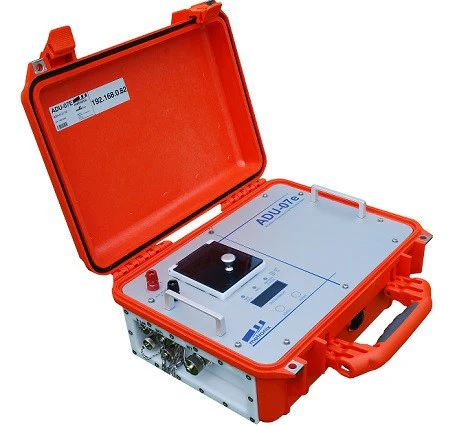

The ADU-07e has a fairly simple to use network interface, simply connect to the machine using ethernet or wifi, and go to IP address listed (LAN for ethernet) (W-LAN for wifi)


#### 4 x Tinker & Rasor Copper-sulfate electrodes Model 6-B

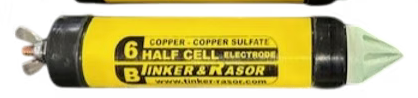


#### 3 x Magnetic flux gates receivers:

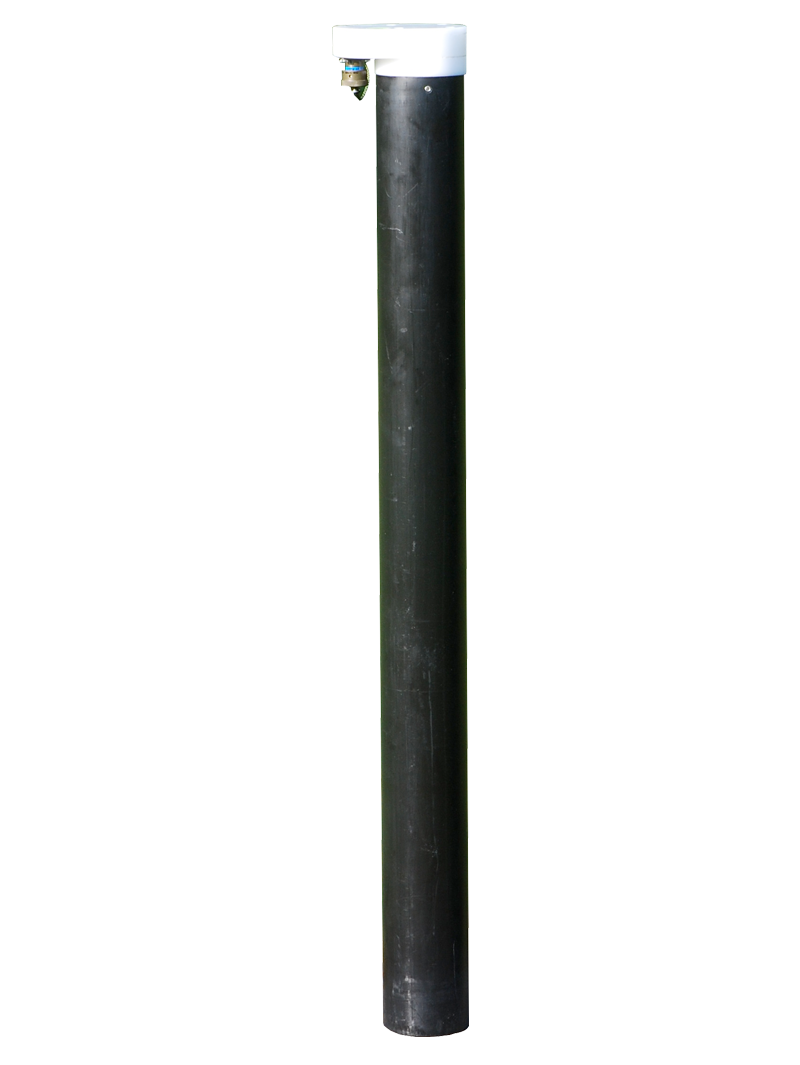

### Today
1. Set up a single 80 meter by 80 meter dipole for the electic field measurement oriented with:
   * The x-component pointing from Guggenheim to Green Center
   * The y-component pointing from CoorsTek to Chuevenet/Stratton
1. Set up three magnetic field sensors
   * Two horizontals oriented in the same direction as above
   * One vertical
   * Do not dig holes in the commons!
1. Set the instrument to record data at 512 Hz
1. Then come back inside
1. At the end of class we will go collect the instrument.

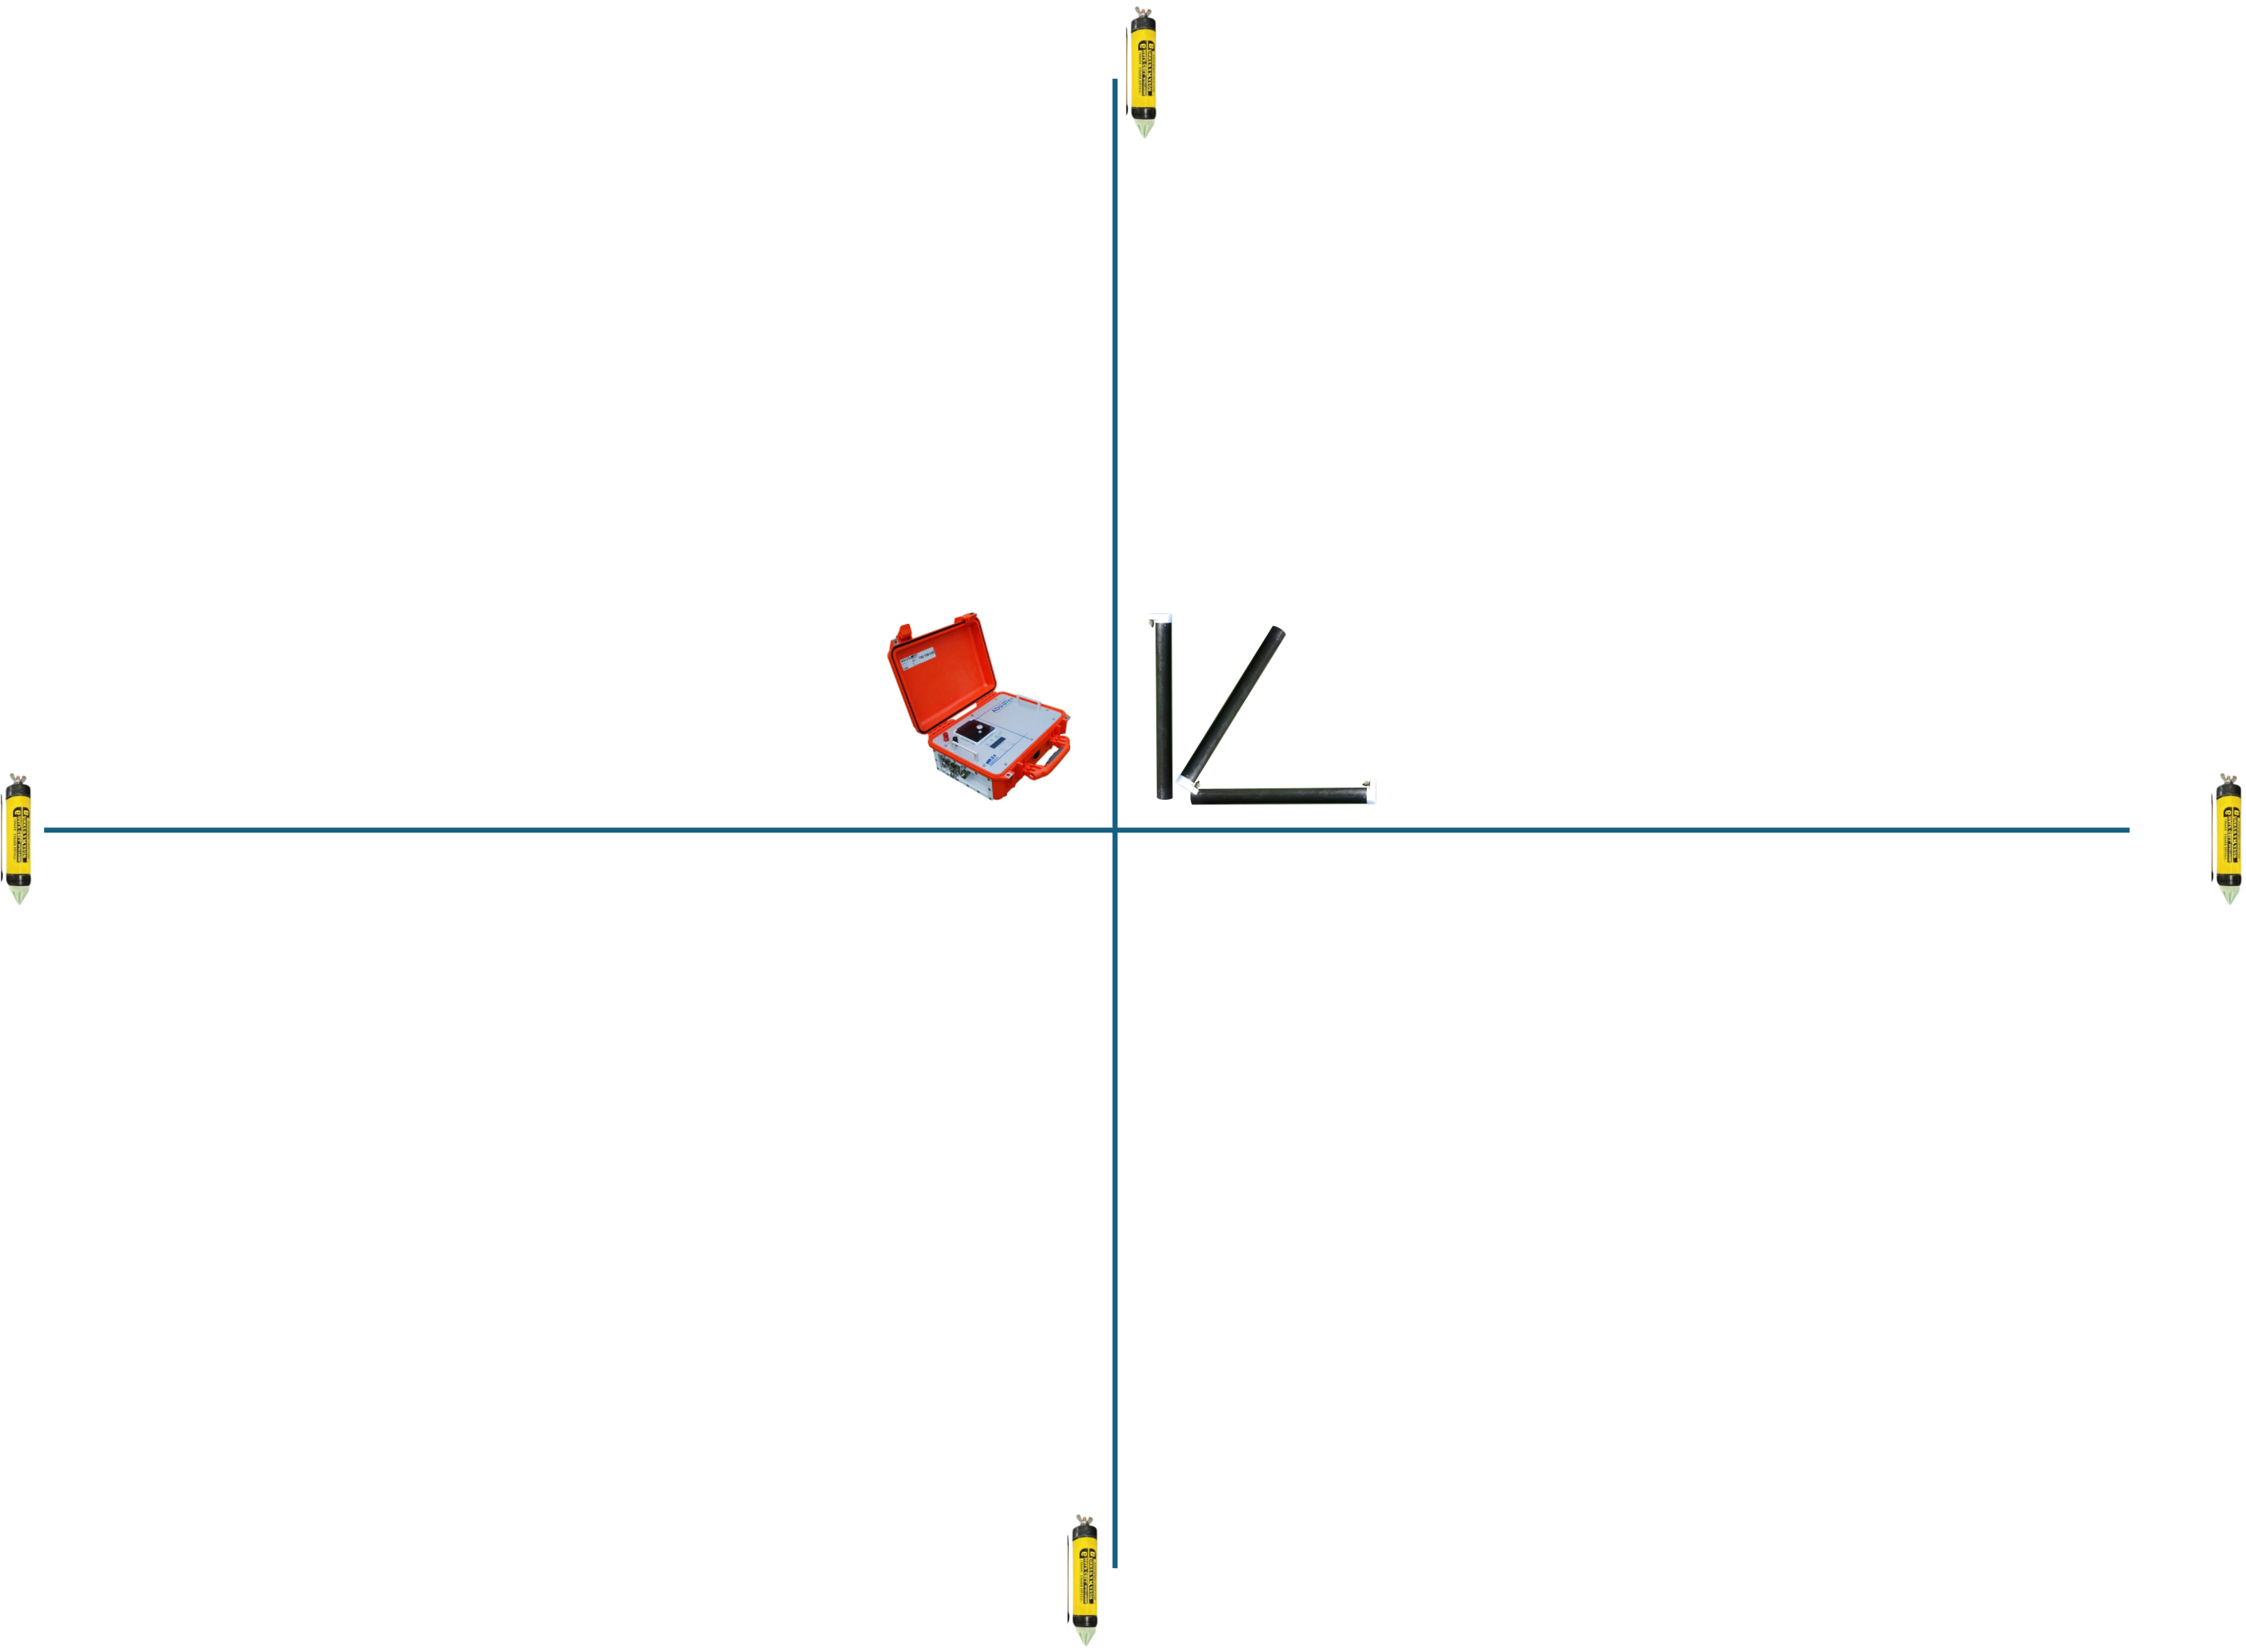

### Safety
* We will be working with a 12V battery, so be cognizant of matching positive and negative terminals

* We will be leaving the instrument to record data while we are working inside
    * Kafadar usually has a lot of foot traffic
    * We won't be there to warn people of the long **small** wires
    * Need to minimze trip hazards for others, (and so they don't disconnect our wires)
    * Likely place flags along the wires in the grass.
    * Some wire guards for side-walk crossings will be useful

## Deliverables
* Copy of relevant field notebook
* Plots of the amplitude and phase spectrums of the recorded data (as a function of frequency)
    * Make observations about any spikes you might see in the spectrums.
    * How do the phases of the Electric field and the Magnetic fields compare?

### Example: Plotting frequency spectrums of time-series data
As an example, I'm going to generate a synthetic time series and plot it's frequency spectrum

In [2]:
import numpy as np
import matplotlib.pyplot as plt

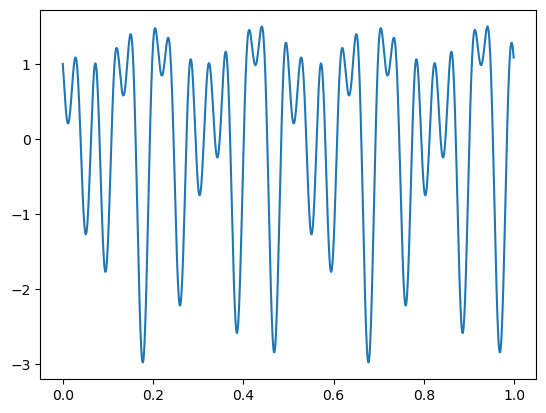

In [3]:
dt = 1E-3 # 1 ms
n_samples = 1000

t = np.arange(n_samples) * dt

# signal has three frequencies, 10Hz, 14Hz, and 24Hz
# 10Hz is a sine wave: -90 degrees (from cosine)
# 14Hz is a cosine wave : 0 degrees phase
# 24Hz is a negative sine wave : +90 degrees phase (from cosine)
s_t  = np.sin(2 * np.pi * 10 * t) + np.cos(2 * np.pi * 14 * t) - np.sin(2 * np.pi * 24 *t)

plt.plot(t, s_t)

In [4]:
# Do an fft!

# use numpy's real fft function because s_t is real (not complex) data, it's output is still complex though.
s_tilde = np.fft.rfft(s_t)

# numpy also conveniently has a function to give you the frequencies asssociated with s_tilde
freqs = np.fft.rfftfreq(len(s_t), dt)

Text(0, 0.5, '$\\theta$')

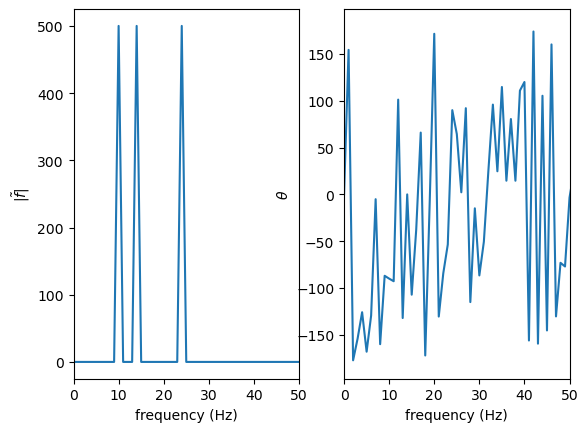

In [5]:
# plotting the frequency spectrum from 0 to 50Hz (note the full range goes from 0 to 500Hz
plt.figure()
plt.subplot(1,2,1)
plt.plot(freqs, np.abs(s_tilde))
plt.xlim([0, 50])
plt.xlabel('frequency (Hz)')
plt.ylabel(r'$|\tilde{f}|$')

plt.subplot(1,2,2)
plt.plot(freqs, np.angle(s_tilde, deg=True))
plt.xlim([0, 50])
plt.xlabel('frequency (Hz)')
plt.ylabel(r"$\theta$")

Since the "signal" I generated had 3 different frequencies (10Hz, 14Hz, and 24Hz), we should expect to see 3 spikes in the amplitude spectrum at those frequencies.

> For this example the phases are mostly all over the place due to small numerical noise,
> But the phases specfically at our three frequencies should make sense

> **Note** For this toy example $\delta f=1$, so if I want to see the amplitude and phase at frequency 10, I can just index the transformed data at 10. This is not always the case

In [6]:
np.abs(s_tilde[10]), np.abs(s_tilde[14]), np.abs(s_tilde[24])

(np.float64(499.9999999999999),
 np.float64(500.00000000000034),
 np.float64(500.0))

In [7]:
np.angle(s_tilde[10], deg=True), np.angle(s_tilde[14], deg=True), np.angle(s_tilde[24], deg=True)

(np.float64(-90.00000000000001),
 np.float64(-3.921902207802177e-14),
 np.float64(89.99999999999991))

You can clearly see the sine wave at 10Hz had a -90 degree phase the cosine wave at 14Hz had zero phase, and the sine wave at 24Hz had 90 degree phase.

## Reading in the binary data from the ADU-07e

Using `numpy`'s `fromfile` function is the quickest way to read in binary formmated data. For the ADU-07e, the `.ats` files contain the time series readings. The time series starts at the 1024 offset in the file, and are encoded as 32bit integers. So you want to specify `fromfile`'s keyword arguments: `dtype=np.int32`, and `offset=1024`


In [8]:
# Using numpy's fromfile
ey = np.fromfile('data/lab4MT/258_V01_C01_R000_TEy_BL_512H.ats', dtype=np.int32, offset=1024)

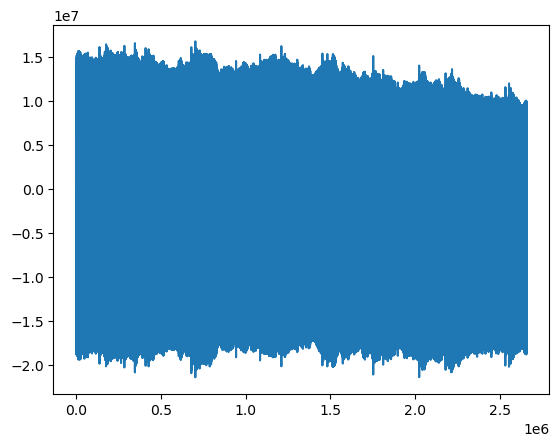

In [9]:
plt.plot(ey)

## A bit above and beyond...

### 60Hz harmonics

I can imagine you expected to see 60 Hz noise in there... but... why is there also a large spike at 180 Hz?

## P.S.
You can listen to the data using `IPython.display.Audio`!

In [13]:
# Audio(ey, rate=512*16) #uncomment this